<a href="https://colab.research.google.com/github/Gaurav13tiwari/repido/blob/gaurav3/EDA(Exploratory_Data_Analysis).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Install & Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import warnings
warnings.filterwarnings('ignore')

# Seaborn theme for clean plots
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print("Libraries loaded successfully")

Libraries loaded successfully


In [ ]:
df = sns.get_dataset_names()
print(df)

['anagrams', 'anscombe', 'attention', 'brain_networks', 'car_crashes', 'diamonds', 'dots', 'dowjones', 'exercise', 'flights', 'fmri', 'geyser', 'glue', 'healthexp', 'iris', 'mpg', 'penguins', 'planets', 'seaice', 'taxis', 'tips', 'titanic']


## Load & Inspect the Dataset
We'll use the Titanic dataset — a classic real-world dataset containing passenger info and survival outcomes. Available directly via seaborn.

In [ ]:
# Load directly from seaborn
df = sns.load_dataset('titanic')

# Also available at Kaggle or via URL:w
# url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
# df = pd.read_csv(url)

print(f"Shape: {df.shape}")
df.head(5)

Shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## Shape & Data Types

In [ ]:
# Basic structure info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [ ]:
# Column-by-column dtype + null count
print("\nColumn dtypes:\n", df.dtypes)


Column dtypes:
 survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object


In [ ]:
print("\nNull counts:\n", df.isnull().sum())


Null counts:
 survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


## Statistical Summary

In [ ]:
# Summary stats for numerical columns
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
# Include categorical columns too
df.describe(include='all')

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Specific percentiles
df['fare'].describe(percentiles=[.10, .25, .50, .75, .90, .99])

,fare
count,891.000000
mean,32.204208
std,49.693429
min,0.000000
10%,7.550000
25%,7.910400
50%,14.454200
75%,31.000000
90%,77.958300
99%,249.006220


## Check Duplicates

In [ ]:
# Find duplicate rows
print(f"Duplicate rows: {df.duplicated().sum()}")

Duplicate rows: 107


In [ ]:
# Drop duplicates if any
df = df.drop_duplicates()

# Unique value counts per column
for col in df.columns:
    print(f"{col}: {df[col].unique()} ")

survived: [0 1] 
pclass: [3 1 2] 
sex: ['male' 'female'] 
age: [22.   38.   26.   35.     nan 54.    2.   27.   14.    4.   58.   20.
 39.   55.   31.   34.   15.   28.    8.   19.   40.   66.   42.   21.
 18.    3.    7.   49.   29.   65.   28.5   5.   11.   45.   17.   32.
 16.   25.    0.83 30.   33.   23.   24.   46.   59.   71.   37.   47.
 14.5  70.5  32.5  12.    9.   36.5  51.   55.5  40.5  44.    1.   61.
 56.   50.   36.   45.5  20.5  62.   41.   52.   63.   23.5   0.92 43.
 60.   10.   64.   13.   48.    0.75 53.   57.   80.   70.   24.5   6.
  0.67 30.5   0.42 34.5  74.  ] 
sibsp: [1 0 3 4 2 5 8] 
parch: [0 1 2 5 3 4 6] 
fare: [  7.25    71.2833   7.925   53.1      8.05     8.4583  51.8625  21.075
  11.1333  30.0708  16.7     26.55    31.275    7.8542  16.      29.125
  13.      18.       7.225   26.       8.0292  35.5     31.3875 263.
   7.8792   7.8958  27.7208 146.5208   7.75    10.5     82.1708  52.
   7.2292  11.2417   9.475   21.      41.5792  15.5     21.6792  17.8
 

In [ ]:
# Unique value counts per column
for col in df.columns:
    print(f"{col}: {df[col].nunique()} ")

survived: 2 
pclass: 3 
sex: 2 
age: 88 
sibsp: 7 
parch: 7 
fare: 248 
embarked: 3 
class: 3 
who: 3 
adult_male: 2 
deck: 7 
embark_town: 3 
alive: 2 
alone: 2 


# Handling Missing Values
Missing data is one of the most common data quality issues. You need to find, visualize, understand the pattern, and then decide how to handle it

In [ ]:
# Detect missing values
# Count and percentage of missing values

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

print(missing_df[missing_df['Missing Count'] > 0])

             Missing Count  Missing %
deck                   582      74.23
age                    106      13.52
embarked                 2       0.26
embark_town              2       0.26


# Imputation Strategies

imputation means to fill data based on stats



In [ ]:
# Strategy 1: Drop columns with too many nulls
df = df.drop(columns=['deck'])

# Strategy 2: Fill with median in case of numerical data
df['age'] = df['age'].fillna(df['age'].median())

# Strategy 3: Fill with mode in case of categorical data
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

# Strategy 4: Group-wise imputation
df['age'] = df.groupby(['pclass', 'sex'])['age'].transform(
    lambda x: x.fillna(x.median())
)

print("Remaining nulls:", df.isnull().sum().sum())

Remaining nulls: 2


In [ ]:
df['embark_town']=df['embark_town'].fillna(df['embark_town'].mode()[0])

# Univariate Analysis
*   Univariate analysis helps us understand individual variables.
*   In Titanic, age shows a roughly normal distribution, while fare is highly right-skewed, indicating most passengers paid low fares with a few high-value outliers.



# Histogram + KDE plot

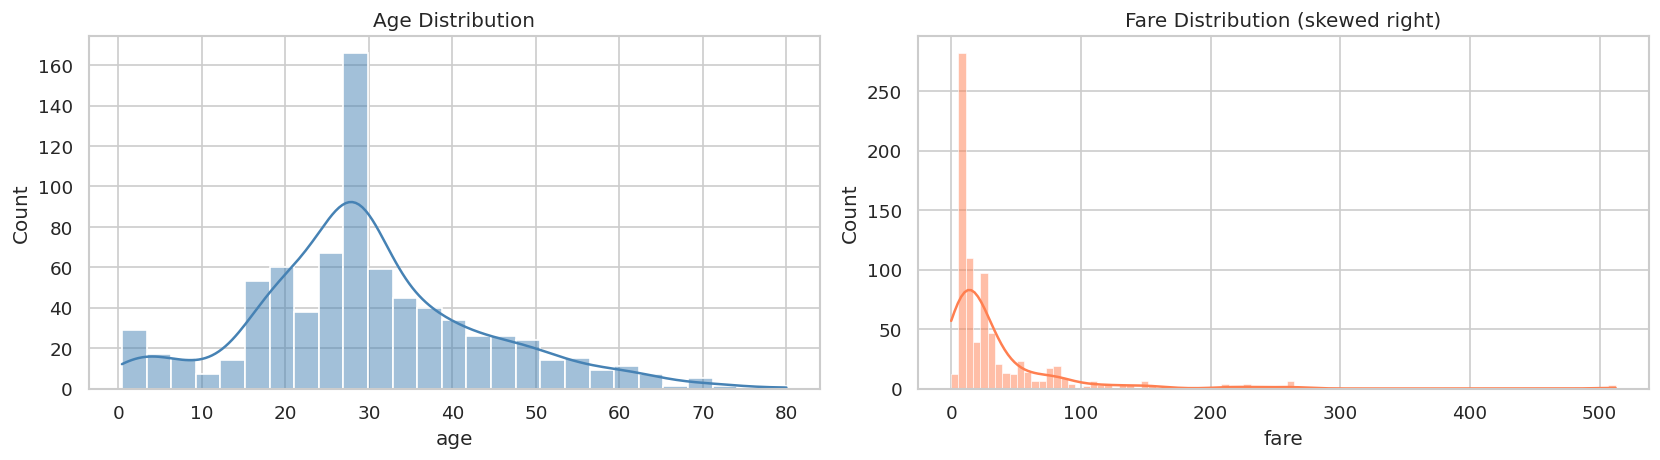

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Age graph
sns.histplot(df['age'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Age Distribution')

# Fare graph
sns.histplot(df['fare'], kde=True, ax=axes[1], color='coral')
axes[1].set_title('Fare Distribution (skewed right)')

plt.tight_layout()
plt.show()

## Age:
Almost normal distribution
Balanced spread

## Fare:
Highly right skewed
Contains outliers (very high ticket prices)

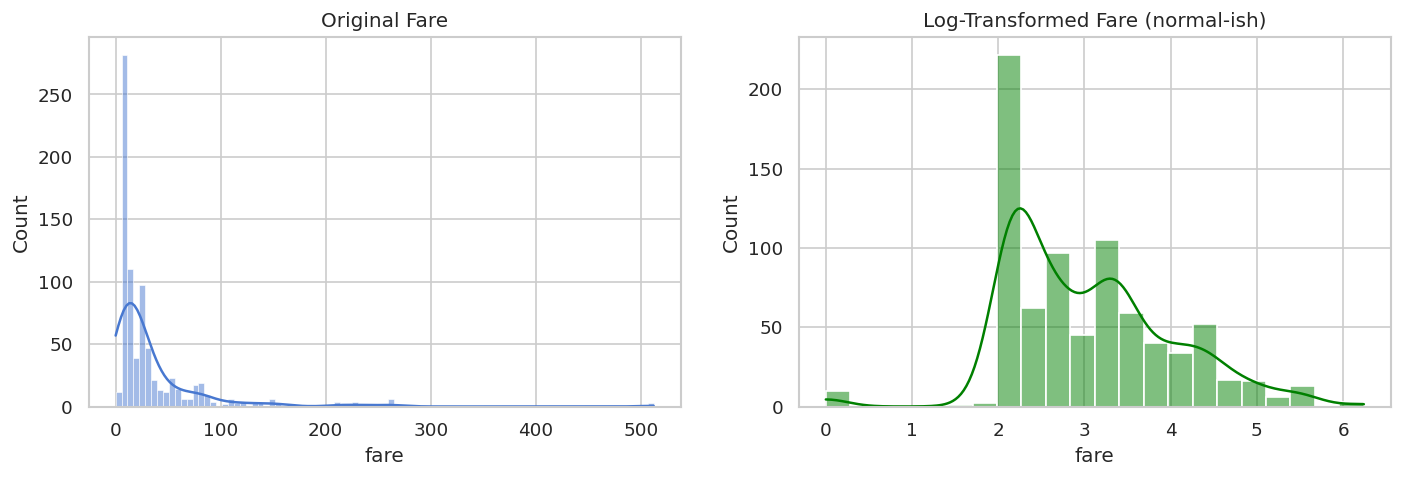

Fare skewness: 4.57
Age skewness:  0.44


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df['fare'], kde=True, ax=axes[0])
axes[0].set_title('Original Fare')

sns.histplot(np.log1p(df['fare']), kde=True, ax=axes[1], color='green')
axes[1].set_title('Log-Transformed Fare (normal-ish)')
plt.show()

# Skewness check
print(f"Fare skewness: {df['fare'].skew():.2f}")
print(f"Age skewness:  {df['age'].skew():.2f}")




*   Most ticket prices are low
*   Few are very high

*   Reduces large values

*   Compresses extreme values
*   Makes distribution more balanced








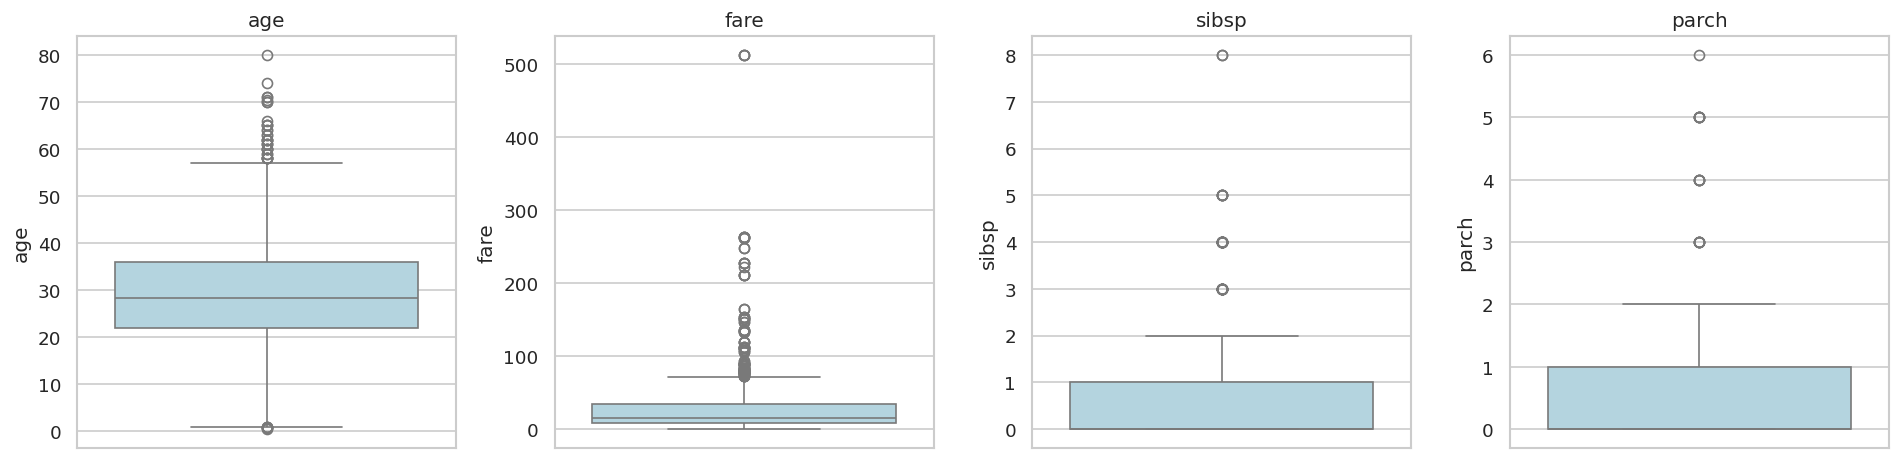

In [ ]:
#Box plot — spotting spread and outliers
# All numerical columns at once

num_cols = ['age', 'fare', 'sibsp', 'parch']

fig, axes = plt.subplots(1, len(num_cols), figsize=(16, 4))
for i, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='lightblue')
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

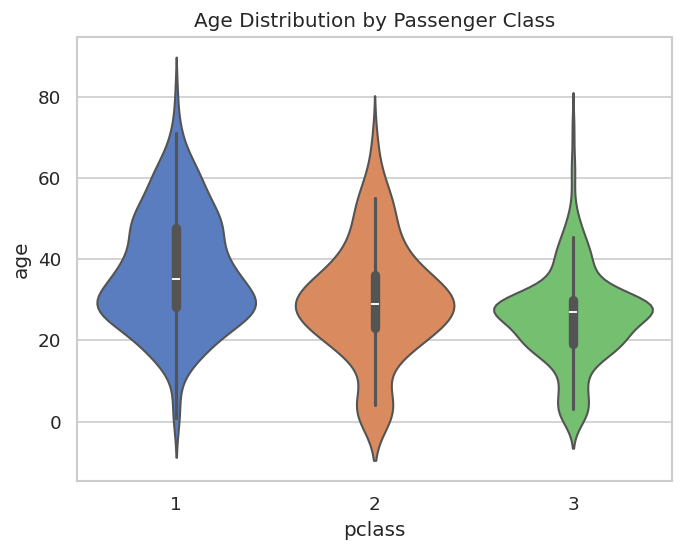

In [ ]:
# Violin = box plot + KDE (shows distribution shape)

sns.violinplot(x='pclass', y='age', data=df,palette='muted', inner='box')
plt.title('Age Distribution by Passenger Class')
plt.show()

# Categorical Variable Analysis
Analyze the frequency, proportion, and relationship of categorical columns with the target variable

## Value counts for categorical columns

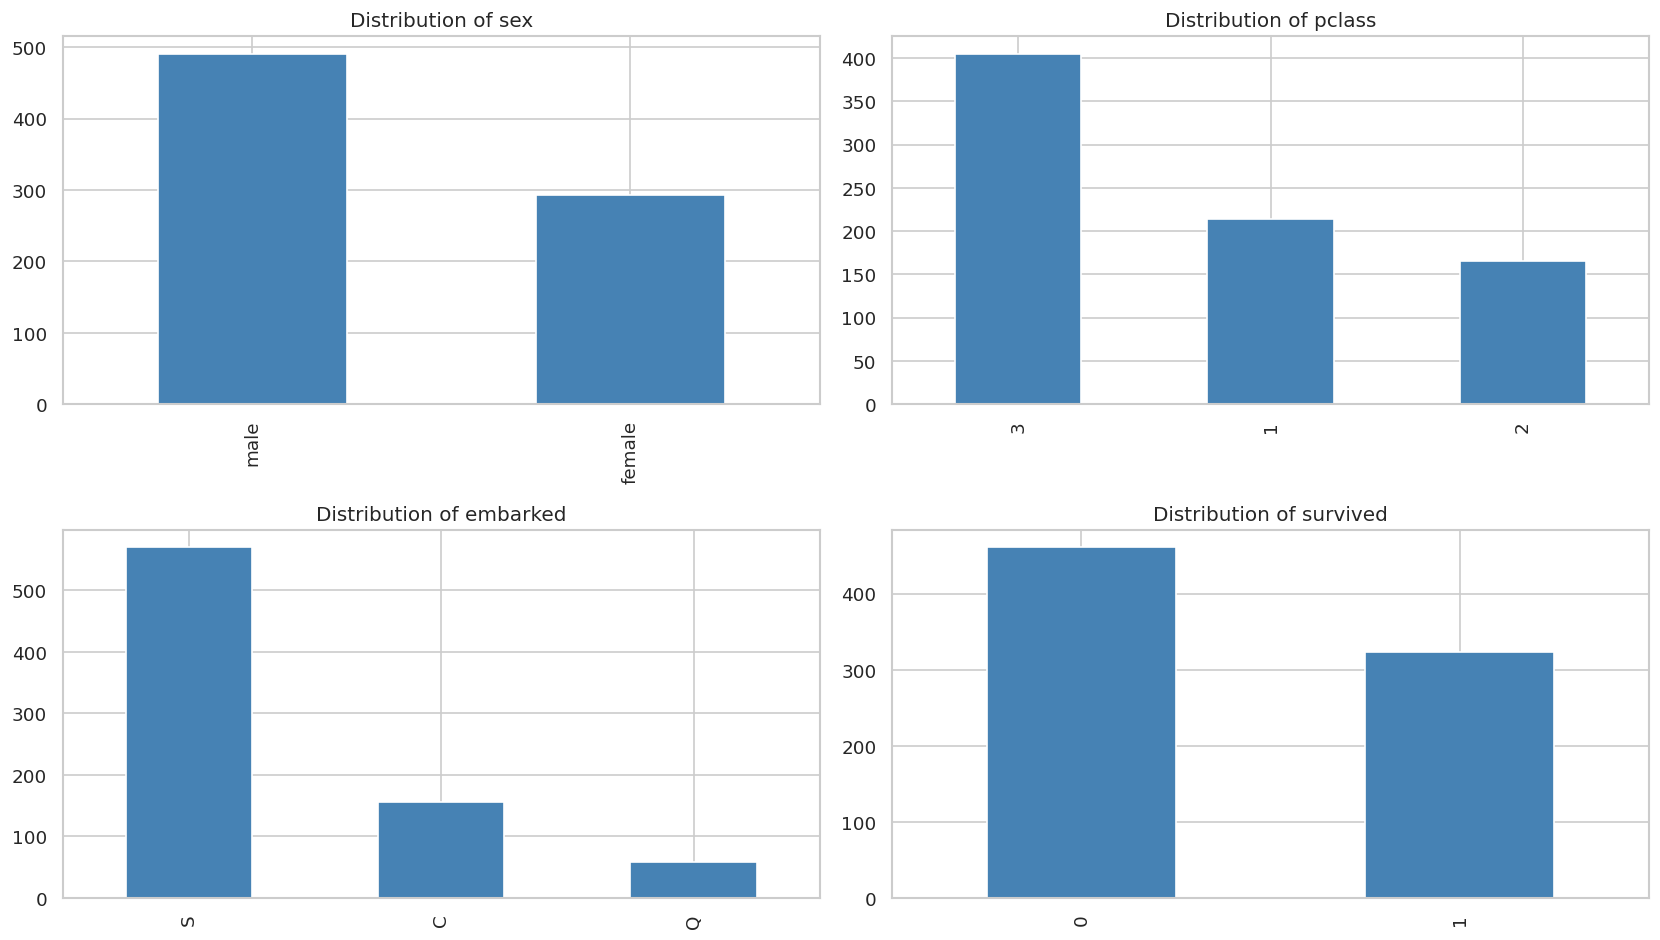

In [ ]:
cat_cols = ['sex', 'pclass', 'embarked', 'survived']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, col in zip(axes.flatten(), cat_cols):
    df[col].value_counts().plot(kind='bar', ax=ax, color='steelblue')
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

### Survival rate by category (bivariate)

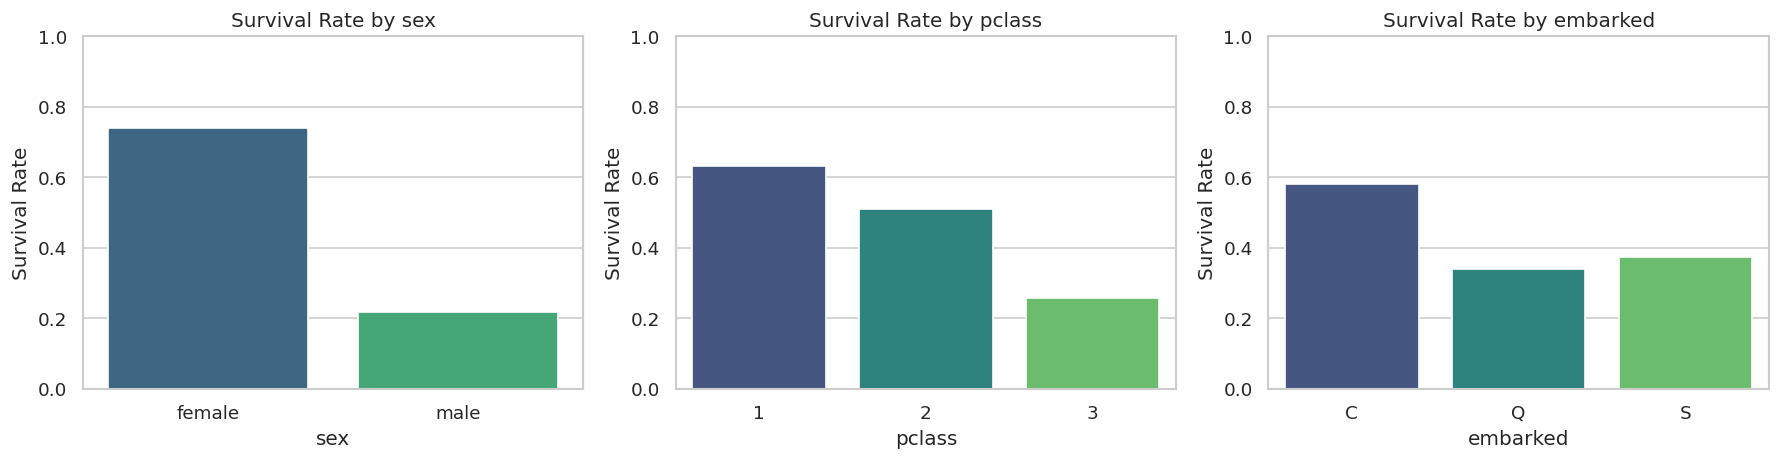

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ['sex', 'pclass', 'embarked']):
    survival = df.groupby(col)['survived'].mean().reset_index()
    sns.barplot(x=col, y='survived', data=survival,
                ax=ax, palette='viridis')
    ax.set_title(f'Survival Rate by {col}')
    ax.set_ylabel('Survival Rate')
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

## Crosstab : frequency tables
Crosstab = Cross Table
*   It is used to compare two categorical columns and count how often combinations occur


survived         0         1
pclass                      
1         0.369159  0.630841
2         0.490909  0.509091
3         0.743210  0.256790
All       0.588010  0.411990


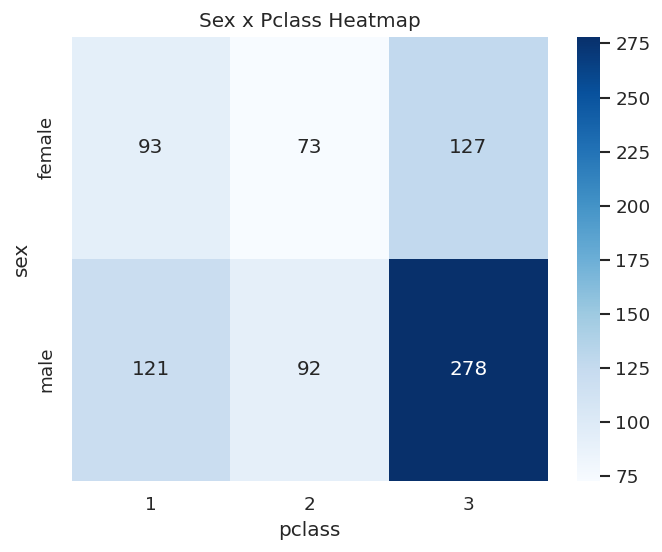

In [ ]:
# Two-way frequency table
ct = pd.crosstab(df['pclass'], df['survived'],
                  margins=True, normalize='index')
print(ct)

# Heatmap of the crosstab
ct2 = pd.crosstab(df['sex'], df['pclass'])
sns.heatmap(ct2, annot=True, fmt='d', cmap='Blues')
plt.title('Sex x Pclass Heatmap')
plt.show()

# Count plot with hue
## hue help  to decide to use diff color to categorize data in columns

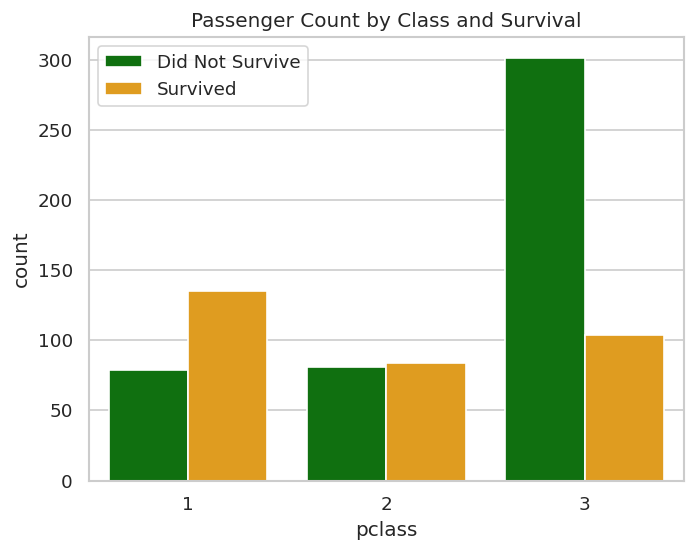

In [ ]:
sns.countplot(x='pclass', hue='survived', data=df,
              palette=['green', 'orange'])
plt.title('Passenger Count by Class and Survival')
plt.legend(labels=['Did Not Survive', 'Survived'])
plt.show()

## Bivariate & Multivariate Analysis
Explore how variables relate to each other and to the target using scatter plots, correlation matrices, and pair plots.

## Correlation heatmap

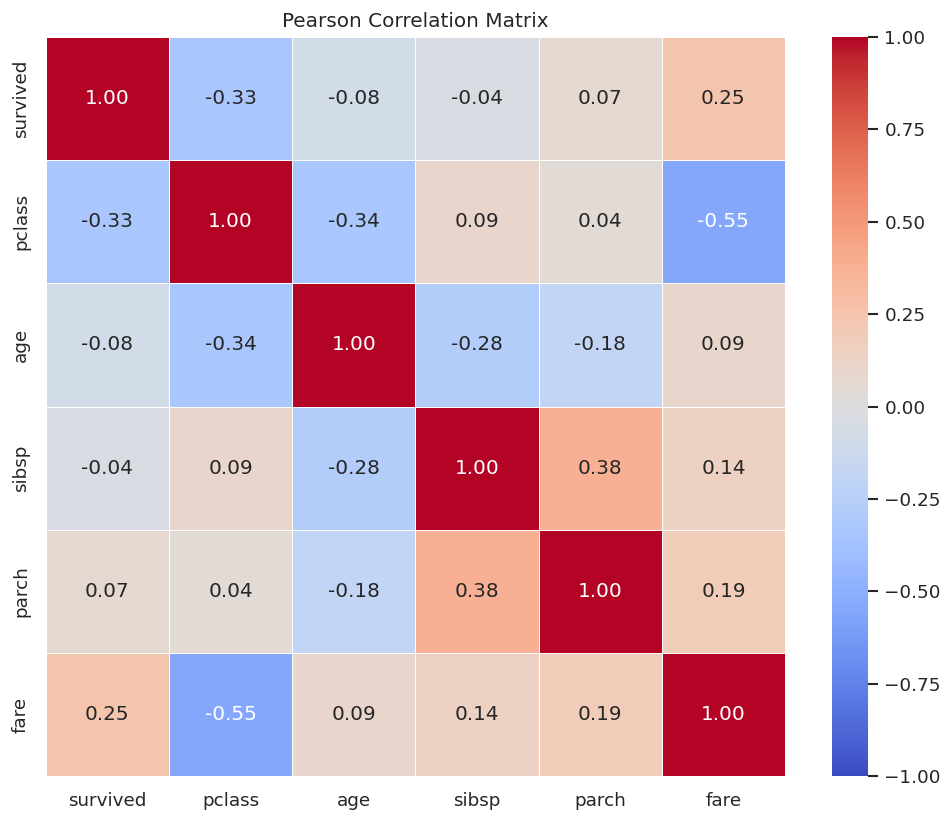

In [ ]:
# Pearson correlation of numerical columns
num_df = df.select_dtypes(include='number')
corr = num_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr,
    annot=True,       # show values
    fmt='.2f',         # 2 decimal places
    cmap='coolwarm',  # colormap
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True
)
plt.title('Pearson Correlation Matrix')
plt.show()

## Scatter plot with regression line

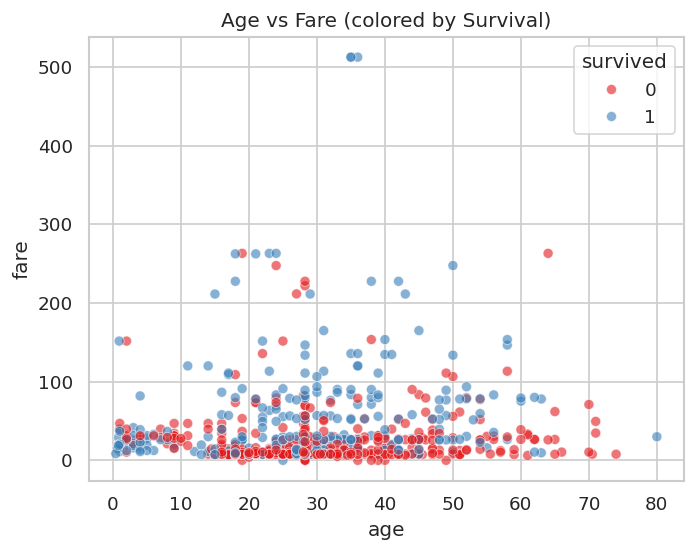

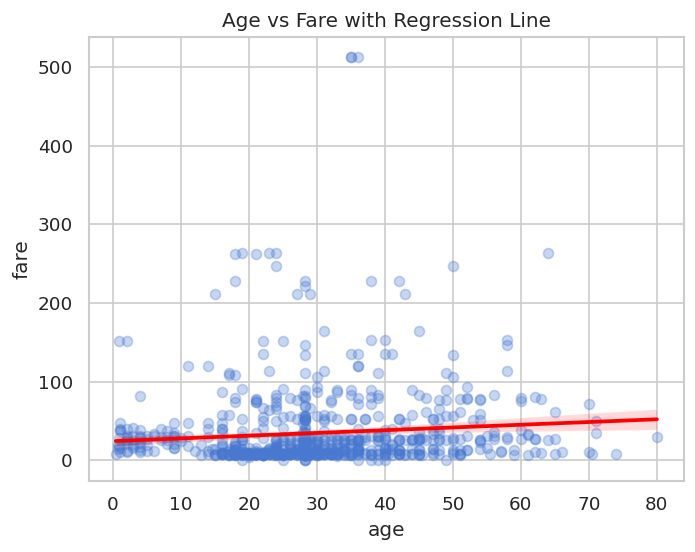

In [ ]:
# Age vs Fare with survival as hue
# Use of Alpha - Makes points slightly transparent (so overlap is visible)

sns.scatterplot(x='age', y='fare', hue='survived',
                data=df, alpha=0.6, palette='Set1')
plt.title('Age vs Fare (colored by Survival)')
plt.show()

# With regression line
sns.regplot(x='age', y='fare', data=df,
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Age vs Fare with Regression Line')
plt.show()

Key Observations:
1. Most people paid low fare
Dense cluster near bottom
Many red points -> more deaths

2. High fare passengers survived more
Upper region has more blue points
Higher fare -> higher survival

3. Age has weak effect
Points spread across all ages
No clear pattern Age alone doesn’t strongly impact fare or survival

4. Some outliers
Very high fare -> 500
Few passengers -> mostly survived

## Pair plot - all combinations at once
Pairplot helps visualize relationships between multiple variables simultaneously. In Titanic, it shows that fare and passenger class strongly influence survival, while age and sibsp have weaker relationships



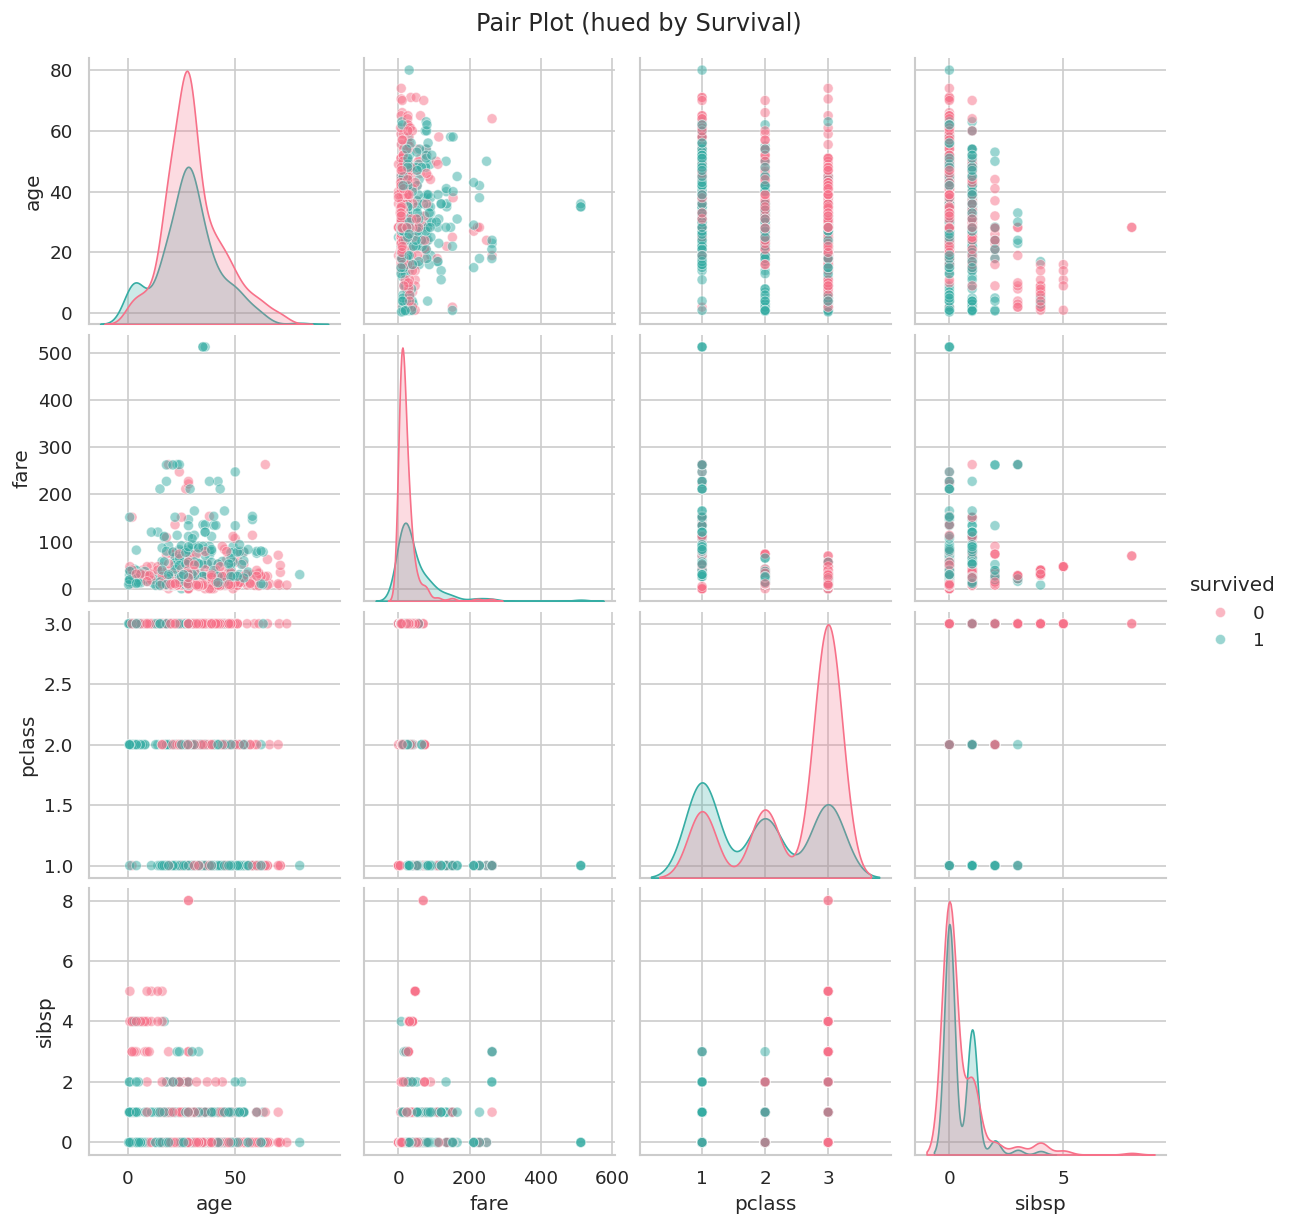

In [ ]:
# Pair plot: scatter matrix for all numeric cols
selected = df[['survived', 'age', 'fare', 'pclass', 'sibsp']]

sns.pairplot(selected,
    hue='survived',
    diag_kind='kde',
    plot_kws={'alpha': 0.5},
    palette='husl'
)
plt.suptitle('Pair Plot (hued by Survival)', y=1.02)
plt.show()

## Key Insights
### 1. Fare vs Survival
*   More Green Button survived at higher fare
*   Rich people survived more

### 2. Pclass vs Survival
*   Class 1 -> more survivors
*   Class 3 ->  more deaths
*   Strong relationship

### 3. Age vs Survival
*   Mixed points
*   No strong pattern

### 4. SibSp vs Survival
*   Most people have 0 - 1
*   No strong survival pattern

### 5. Fare Distribution (Diagonal)
*   Highly skewed
*   Confirms earlier observation

### 6. Pclass Distribution
*   Clearly shows 3 categories
*   Class 3 has more people





# FacetGrid Graph
### FacetGrid allows multi-dimensional analysis by splitting data into subsets.
#### It shows that higher-class passengers tend to be older, while lower-class passengers are generally younger, with visible differences across gender

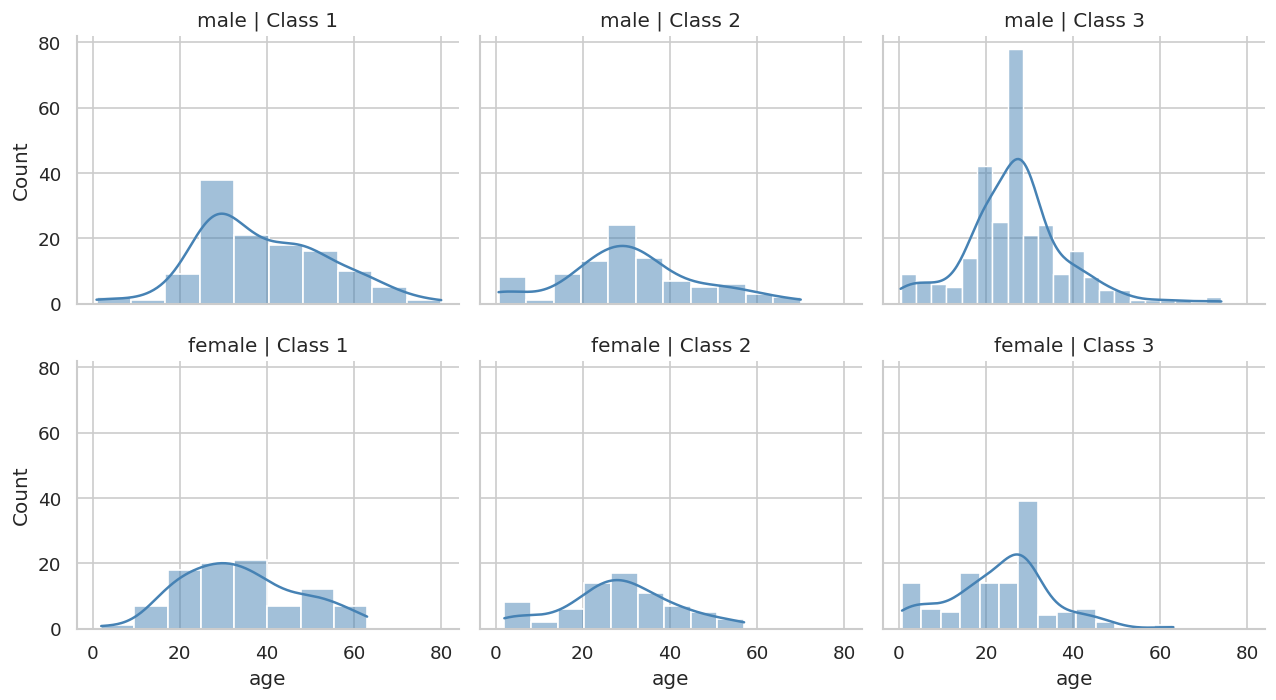

In [ ]:
# Age distribution per class and sex
g = sns.FacetGrid(df, col='pclass', row='sex',
                   height=3, aspect=1.2)
g.map(sns.histplot, 'age', kde=True, color='steelblue')
g.set_titles(col_template="Class {col_name}",
             row_template="{row_name}")
plt.show()

# Outlier Detection & Treatment
## Method 1: IQR (Interquartile Range)
IQR method to detect outliers in fare by calculating Q1, Q3, and defining bounds using 1.5×IQR. Values outside this range are considered outliers, which are common in fare due to its skewed distribution.

In [ ]:
# IQR method — most robust for skewed data
Q1 = df['fare'].quantile(0.25)
Q3 = df['fare'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['fare'] < lower) | (df['fare'] > upper)]
print(f"Fare outliers: {len(outliers)} rows ({len(outliers)/len(df)*100:.1f}%)")
print(f"Bounds: [{lower:.2f}, {upper:.2f}]")

Fare outliers: 102 rows (13.0%)
Bounds: [-31.04, 73.20]


# Method 2: Z-Score (for normal distributions)
### Z-score method identifies age outliers based on standard deviation, while boxplots visually confirm that fare has many outliers due to skewness, whereas age has relatively fewer extreme values

Age outliers (Z > 3): 4


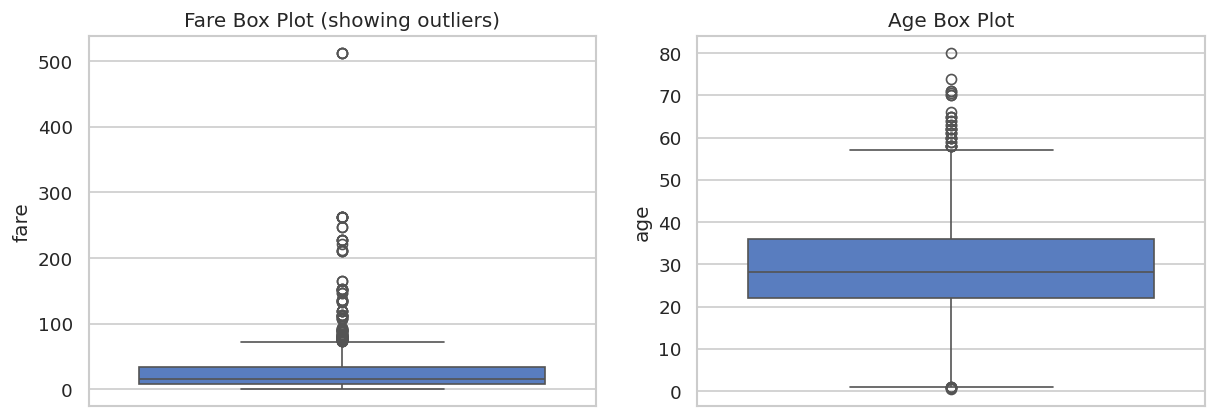

In [ ]:
from scipy import stats

# Z-score: values beyond 3 std devs are outliers
z_scores = np.abs(stats.zscore(df['age'].dropna()))
age_outliers = (z_scores > 3).sum()
print(f"Age outliers (Z > 3): {age_outliers}")

# Visualize with box plot + strip
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(y=df['fare'], ax=ax1)
ax1.set_title('Fare Box Plot (showing outliers)')
sns.boxplot(y=df['age'], ax=ax2)
ax2.set_title('Age Box Plot')
plt.show()

# Feature Engineering Insights
*   Feature Engineering = Creating new useful columns from existing data
*   We transform raw data into better features so ML models can learn patterns more easily

### Why It Is Important
*  Improves model accuracy
*   Captures hidden patterns
*   Uses domain knowledge

In [ ]:
# seaborn  titanic already has a 'who' column: 'man', 'woman', 'child'
df = sns.load_dataset('titanic')

print(df['who'].value_counts())


# Use it directly 'title' equivalent
df['title'] = df['who']  # already clean, no extraction needed

who
man      537
woman    271
child     83
Name: count, dtype: int64


In [ ]:
df = sns.load_dataset('titanic')

# Fixed NaN age before comparison
def assign_title(row):
    age = row['age']
    if pd.isna(age):          # handle missing age first
        if row['sex'] == 'female':
            return 'Mrs'
        else:
            return 'Mr'
    elif age < 13:
        return 'Child'
    elif row['sex'] == 'female':
        return 'Mrs' if age >= 18 else 'Miss'
    else:
        return 'Mr'

df['title'] = df.apply(assign_title, axis=1)
print(df['title'].value_counts())

title
Mr       540
Mrs      259
Child     69
Miss      23
Name: count, dtype: int64


#### Instead of just sibsp and parch
#### Create family_size -> more meaningful

In [ ]:
# Family size
df['family_size'] = df['sibsp'] + df['parch'] + 1
df['is_alone'] = (df['family_size'] == 1).astype(int)

# Fare per person
df['fare_per_person'] = df['fare'] / df['family_size']

# Age groups (also handle NaN)
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 12, 18, 35, 60, 100],
    labels=['Child', 'Teen', 'Young Adult', 'Adult', 'Senior']
)

# Verify no errors
print(df[['title', 'family_size', 'is_alone', 'fare_per_person', 'age_group']].head(10))
print("\nAny nulls?", df[['title', 'family_size', 'is_alone']].isnull().sum().sum())

   title  family_size  is_alone  fare_per_person    age_group
0     Mr            2         0          3.62500  Young Adult
1    Mrs            2         0         35.64165        Adult
2    Mrs            1         1          7.92500  Young Adult
3    Mrs            2         0         26.55000  Young Adult
4     Mr            1         1          8.05000  Young Adult
5     Mr            1         1          8.45830          NaN
6     Mr            1         1         51.86250        Adult
7  Child            5         0          4.21500        Child
8    Mrs            3         0          3.71110  Young Adult
9   Miss            2         0         15.03540         Teen

Any nulls? 0


## Validate new features with EDA

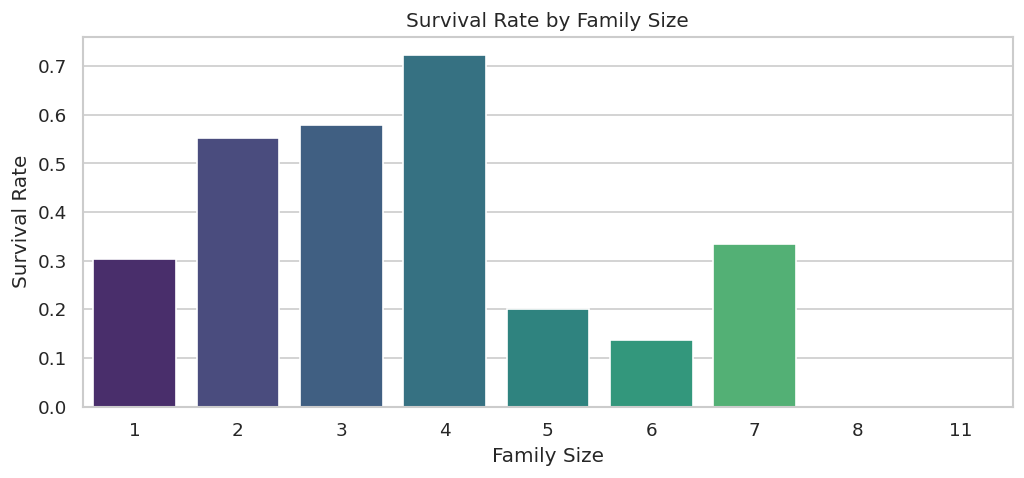

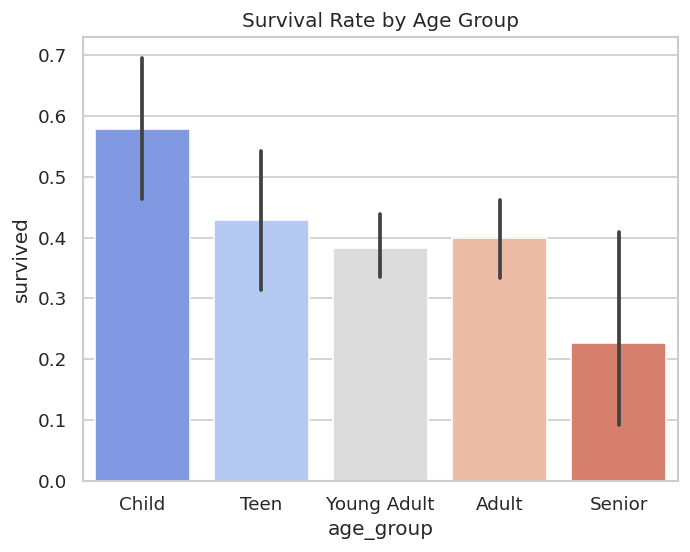

In [ ]:
# Does family size affect survival?
surv_by_family = df.groupby('family_size')['survived'].mean()

plt.figure(figsize=(10, 4))
sns.barplot(x=surv_by_family.index, y=surv_by_family.values,
            palette='viridis')
plt.title('Survival Rate by Family Size')
plt.xlabel('Family Size')
plt.ylabel('Survival Rate')
plt.show()

# Age group survival
sns.barplot(x='age_group', y='survived', data=df,
            palette='coolwarm')
plt.title('Survival Rate by Age Group')
plt.show()

# Encoding categorical variables
*   Label encoding is used for binary variables
*   One-hot encoding for nominal variables without order
*   Ordinal encoding for features with a natural ranking


In [ ]:
# Label encoding (ordinal)
df['sex_encoded'] = df['sex'].map({'male': 0, 'female': 1})

# One-hot encoding (nominal)
df_encoded = pd.get_dummies(df, columns=['embarked'], prefix='emb')

# Ordinal encoding for pclass
from sklearn.preprocessing import OrdinalEncoder
oe = OrdinalEncoder()
df['age_group_enc'] = oe.fit_transform(
    df[['age_group']].astype(str)
)

# Automated EDA Libraries
1. ydata-profiling (formerly pandas-profiling)
*  ydata-profiling is used to generate automated EDA reports that
include distributions, correlations, missing values, and warnings, helping quickly understand the dataset before modeling.





In [ ]:
!pip install ydata-profiling -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 27.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 26.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 71.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 31.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 4.5 MB/s eta 0:00:00


In [ ]:
from ydata_profiling import ProfileReport
profile = ProfileReport(
    df,
    title='Titanic EDA Report',
    explorative=True
)

# Display inline in Colab
profile.to_notebook_iframe()

# Optional: save as HTML file
profile.to_file('titanic_eda_report.html')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 22/22 [00:00<00:00, 36.51it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]